# **Libraries**

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

# **Data Collecting**

In [40]:
df = pd.read_csv('../../data/synthetic_data.csv')
df = df.set_index("timestamp_prediction")
df = df.sort_index()

In [41]:
df.head(10)

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2025-01-01 06:00:00,Cakung,1,Tps 3R,582666,8392,2,0,0,0.85,14.0,0.0,14.28,78.91
2025-01-01 06:00:00,Pulogadung,126,Tipe 2,296845,1639,2,0,0,1.50,15.4,2.7,17.44,70.80
2025-01-01 06:00:00,Cakung,2,Tipe 1,582666,2197,2,0,0,1.84,16.8,0.0,8.70,77.29
2025-01-01 06:00:00,Mampang Prapatan,86,Tipe 2,168340,1071,2,0,0,0.97,24.9,0.0,13.65,36.90
2025-01-01 06:00:00,Duren Sawit,31,Tipe 4,444264,6541,2,0,0,2.91,15.4,0.0,16.94,92.08
2025-01-01 06:00:00,Cilincing,17,Tipe 2,444380,1304,2,0,0,1.05,4.9,0.0,19.15,88.47
2025-01-01 06:00:00,Tanjung Priok,145,Tipe 1,418090,1925,2,0,0,2.26,8.8,0.0,12.39,74.67
2025-01-01 06:00:00,Kelapa Gading,66,Tipe 4,162840,8050,2,0,0,2.17,8.8,3.0,21.13,66.11
2025-01-01 06:00:00,Mampang Prapatan,87,Tipe 3,168340,3104,2,0,0,1.59,24.9,0.0,20.53,41.33


# **Exploratory Data Analysis**

In [42]:
df.info()

<class 'pandas.DataFrame'>
Index: 81900 entries, 2025-01-01 06:00:00 to 2026-06-30 06:00:00
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   kecamatan                81900 non-null  str    
 1   tps_id                   81900 non-null  int64  
 2   tps_type                 81900 non-null  str    
 3   zone_population          81900 non-null  int64  
 4   tps_capacity_kg          81900 non-null  int64  
 5   day_of_week              81900 non-null  int64  
 6   is_weekend               81900 non-null  int64  
 7   is_holiday               81900 non-null  int64  
 8   daily_growth_rate        81900 non-null  float64
 9   rainfall_today           81900 non-null  float64
 10  event_urgency_score      81900 non-null  float64
 11  current_fill_percentage  81900 non-null  float64
 12  target_fill_percentage   81900 non-null  float64
dtypes: float64(5), int64(6), str(2)
memory usage: 8.7+ MB


In [43]:
df.duplicated().sum()

0

In [44]:
df.isna().sum()

kecamatan                  0
tps_id                     0
tps_type                   0
zone_population            0
tps_capacity_kg            0
day_of_week                0
is_weekend                 0
is_holiday                 0
daily_growth_rate          0
rainfall_today             0
event_urgency_score        0
current_fill_percentage    0
target_fill_percentage     0
dtype: int64

In [45]:
df.nunique()

kecamatan                     44
tps_id                       150
tps_type                       5
zone_population               44
tps_capacity_kg              150
day_of_week                    7
is_weekend                     2
is_holiday                     2
daily_growth_rate            251
rainfall_today               445
event_urgency_score           32
current_fill_percentage     5514
target_fill_percentage     10335
dtype: int64

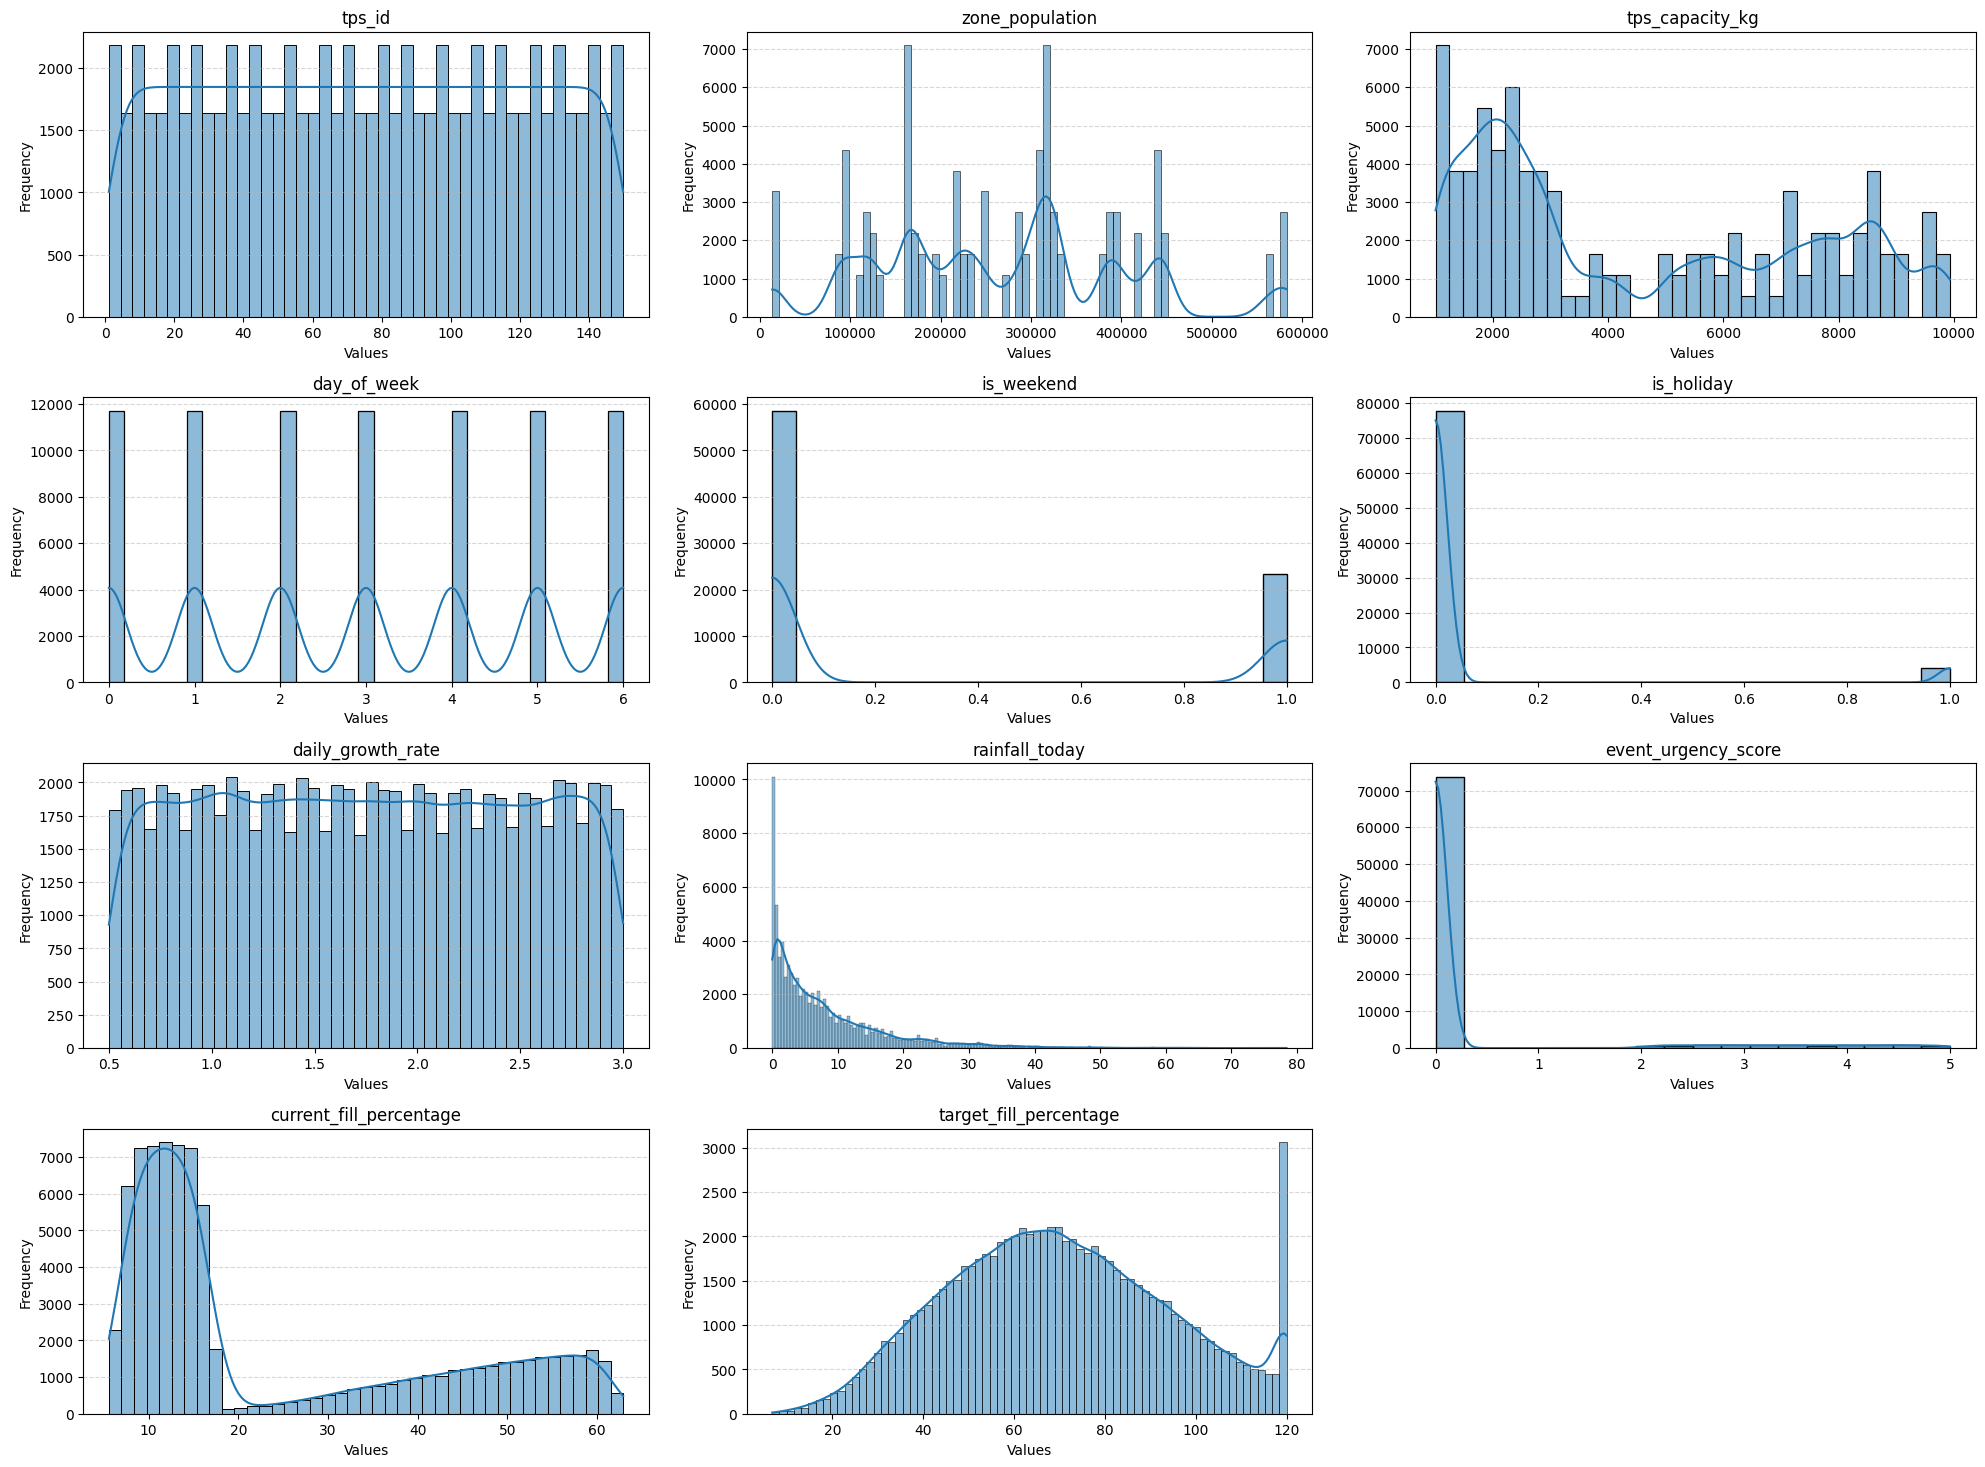

In [46]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, ax = plt.subplots(5, 3, figsize=(20,18))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=ax[i], kde=True)
    ax[i].set_title(col)
    ax[i].set_xlabel("Values")
    ax[i].set_ylabel("Frequency")
    ax[i].grid(axis='y', alpha=0.5, linestyle='--')


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

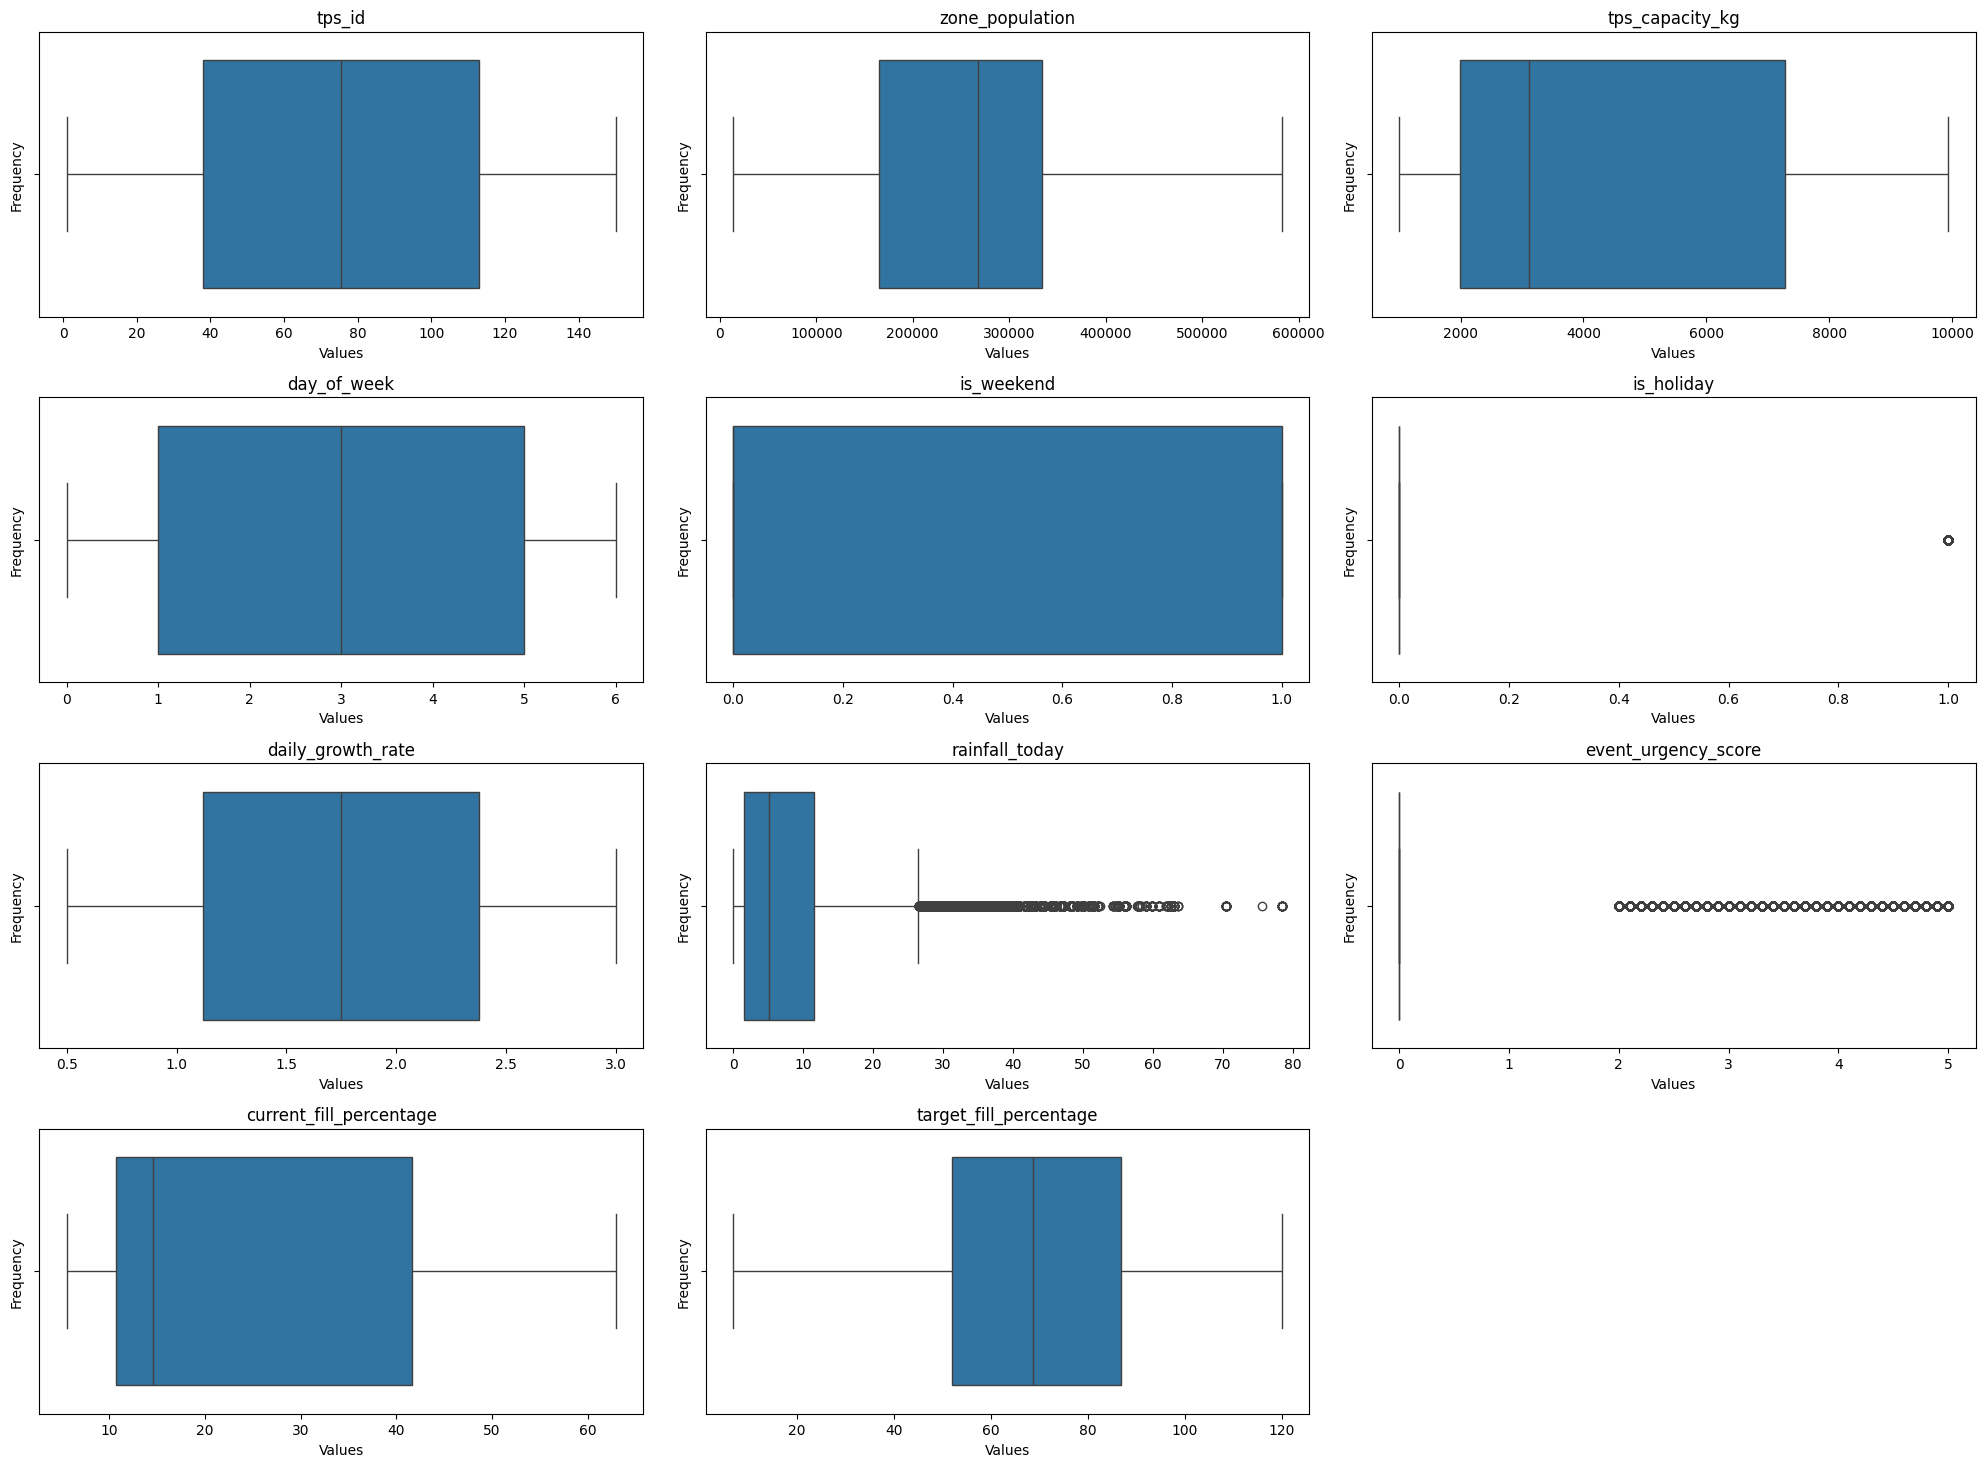

In [47]:
fig, ax = plt.subplots(5, 3, figsize=(20,18))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(df[col], ax=ax[i], orient="h")
    ax[i].set_title(col)
    ax[i].set_xlabel("Values")
    ax[i].set_ylabel("Frequency")


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

In [48]:
print(df["kecamatan"].unique())

<StringArray>
[                  'Cakung',               'Pulogadung',
         'Mampang Prapatan',              'Duren Sawit',
                'Cilincing',            'Tanjung Priok',
            'Kelapa Gading',                   'Gambir',
               'Jatinegara',             'Pesanggrahan',
                'Kemayoran',               'Pasar Rebo',
                 'Matraman',                  'Tambora',
              'Kebon Jeruk',                 'Cilandak',
              'Sawah Besar',                'Jagakarsa',
 'Kepulauan Seribu Selatan',                 'Cipayung',
              'Tanah Abang',                'Kembangan',
   'Kepulauan Seribu Utara',                  'Ciracas',
              'Kramat Jati',                  'Makasar',
              'Penjaringan',                'Setiabudi',
                  'Menteng',        'Grogol Petamburan',
            'Cempaka Putih',                'Kalideres',
                    'Senen',                 'Pancoran',
                 

In [49]:
for i in df["tps_id"].unique():
    tps_id = i

    capacity = df.groupby("tps_id")["tps_capacity_kg"]

In [50]:
df.groupby("tps_id")["tps_capacity_kg"].first().to_dict()

{1: 8392,
 2: 2197,
 3: 2129,
 4: 4056,
 5: 6584,
 6: 5158,
 7: 2493,
 8: 8472,
 9: 6651,
 10: 1194,
 11: 6295,
 12: 1834,
 13: 2016,
 14: 5458,
 15: 5244,
 16: 1706,
 17: 1304,
 18: 6084,
 19: 2327,
 20: 2649,
 21: 4080,
 22: 8747,
 23: 5691,
 24: 2640,
 25: 1924,
 26: 3733,
 27: 9926,
 28: 7275,
 29: 2723,
 30: 1914,
 31: 6541,
 32: 7931,
 33: 2297,
 34: 1647,
 35: 3683,
 36: 7915,
 37: 2545,
 38: 3700,
 39: 8250,
 40: 7423,
 41: 1463,
 42: 2985,
 43: 3502,
 44: 7224,
 45: 1158,
 46: 1035,
 47: 4932,
 48: 5770,
 49: 2105,
 50: 7118,
 51: 6015,
 52: 1196,
 53: 1783,
 54: 9932,
 55: 2854,
 56: 1844,
 57: 3122,
 58: 8993,
 59: 1623,
 60: 1643,
 61: 5709,
 62: 1276,
 63: 9071,
 64: 2491,
 65: 2794,
 66: 8050,
 67: 1213,
 68: 2445,
 69: 8503,
 70: 8557,
 71: 1328,
 72: 2968,
 73: 9569,
 74: 5059,
 75: 2022,
 76: 7063,
 77: 6935,
 78: 1826,
 79: 1142,
 80: 7716,
 81: 2356,
 82: 1424,
 83: 4173,
 84: 5961,
 85: 2039,
 86: 1071,
 87: 3104,
 88: 8675,
 89: 2294,
 90: 1695,
 91: 9673,
 92: 292

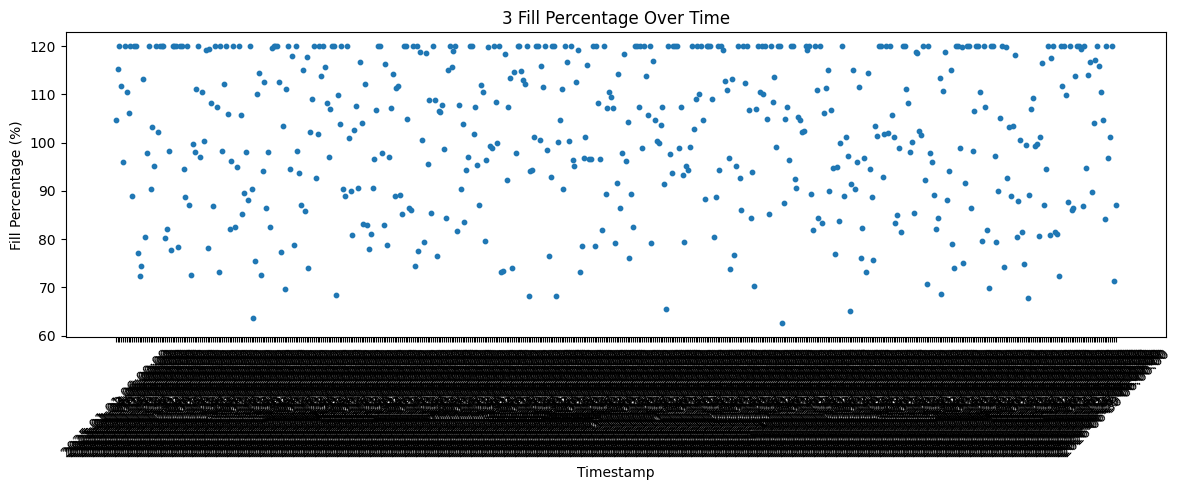

In [51]:
subset = df[df["tps_id"] == 3]

plt.figure(figsize=(12, 5))

plt.scatter(
    subset.index,
    subset["target_fill_percentage"],
    s=10  # dot size
)

plt.xlabel("Timestamp")
plt.ylabel("Fill Percentage (%)")
plt.title(f"{subset['tps_id'].iloc[0]} Fill Percentage Over Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [52]:
preproc_df = df.copy()
preproc_df.tail()

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2026-06-30 06:00:00,Palmerah,98,Tipe 1,199630,1900,1,0,0,2.10,0.1,0.0,11.20,45.59
2026-06-30 06:00:00,Pademangan,97,Tipe 4,193890,9620,1,0,0,1.24,0.5,0.0,8.61,38.16
2026-06-30 06:00:00,Pademangan,96,Tipe 2,193890,1615,1,0,0,1.05,0.5,0.0,14.30,44.19
2026-06-30 06:00:00,Menteng,94,Tipe 4,85016,8203,1,0,0,2.93,0.1,0.0,11.11,39.86
2026-06-30 06:00:00,Tebet,150,Tipe 4,222340,7496,1,0,0,2.20,0.2,0.0,47.71,81.35


## **Train Test Split**

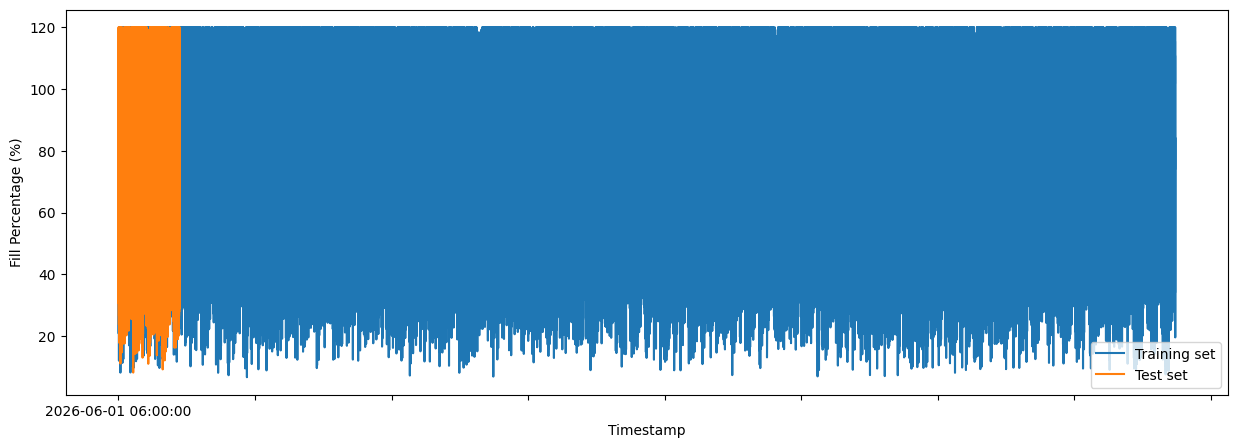

In [53]:
train = preproc_df.loc[preproc_df.index <= "2026-05-31 06:00:00"]
test = preproc_df.loc[preproc_df.index > "2026-05-31 06:00:00"]

fig, ax = plt.subplots(figsize=(15,5))
train["target_fill_percentage"].plot(ax=ax, label="Training set")
test["target_fill_percentage"].plot(ax=ax, label="Test set")

ax.set_xlabel("Timestamp")
ax.set_ylabel("Fill Percentage (%)")
ax.legend()

plt.show()

## **Label Encoding**

In [54]:
encoders = joblib.load("encoders.pkl")

for col, encoder in encoders.items():
    print(f"\n=== {col} ===")
    for i, label in enumerate(encoder.classes_):
        print(f"{label} -> {i}")


=== kecamatan ===
Cakung -> 0
Cempaka Putih -> 1
Cengkareng -> 2
Cilandak -> 3
Cilincing -> 4
Cipayung -> 5
Ciracas -> 6
Duren Sawit -> 7
Gambir -> 8
Grogol Petamburan -> 9
Jagakarsa -> 10
Jatinegara -> 11
Johar Baru -> 12
Kalideres -> 13
Kebayoran Baru -> 14
Kebayoran Lama -> 15
Kebon Jeruk -> 16
Kelapa Gading -> 17
Kemayoran -> 18
Kembangan -> 19
Kepulauan Seribu Selatan -> 20
Kepulauan Seribu Utara -> 21
Koja -> 22
Kramat Jati -> 23
Makasar -> 24
Mampang Prapatan -> 25
Matraman -> 26
Menteng -> 27
Pademangan -> 28
Palmerah -> 29
Pancoran -> 30
Pasar Minggu -> 31
Pasar Rebo -> 32
Penjaringan -> 33
Pesanggrahan -> 34
Pulogadung -> 35
Sawah Besar -> 36
Senen -> 37
Setiabudi -> 38
Taman Sari -> 39
Tambora -> 40
Tanah Abang -> 41
Tanjung Priok -> 42
Tebet -> 43

=== tps_type ===
Tipe 1 -> 0
Tipe 2 -> 1
Tipe 3 -> 2
Tipe 4 -> 3
Tps 3R -> 4


In [55]:
encoding_cols = [
    "kecamatan",
    "tps_type"
]

encoders = {}

for col in encoding_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

In [56]:
train.dtypes

kecamatan                    int32
tps_id                       int64
tps_type                     int32
zone_population              int64
tps_capacity_kg              int64
day_of_week                  int64
is_weekend                   int64
is_holiday                   int64
daily_growth_rate          float64
rainfall_today             float64
event_urgency_score        float64
current_fill_percentage    float64
target_fill_percentage     float64
dtype: object

In [57]:
for col in encoding_cols:
    le = encoders[col]
    test[col] = le.transform(test[col])

In [58]:
for col in encoding_cols:
    unseen = set(test[col].unique()) - set(train[col].unique())
    print(col, unseen)

kecamatan set()
tps_type set()


In [59]:
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

## **Split into X and y**

In [60]:
TARGET = "target_fill_percentage"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

In [61]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(77400, 12)
(4500, 12)
(77400,)
(4500,)


# **Training**

In [62]:
models = {
    "Random Forest Regressor": (
        RandomForestRegressor(random_state=42), 
        {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 3, 5],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt", "log2"]
        }
    ),

    "Gradient Boosting Regressor": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1, 0.3],
            "max_depth": [5, 7],
            "subsample": [0.8, 1.0]
        }
    )
}

In [63]:
timeseriescv = TimeSeriesSplit(n_splits=5)

In [64]:
results = []

for name, (model, params) in models.items():
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=timeseriescv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=2,
        refit=True,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse,
        "R2": r2,
        "Best Params": grid.best_params_,
        "Best CV Score": -grid.best_score_,
        "Estimator": best_model
    })

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [65]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("MAE")

results_df

,Model,MAE,MAPE,RMSE,R2,Best Params,Best CV Score,Estimator
1,Gradient Boosting Regressor,7.387398,0.114461,9.313158,0.852790,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",7.388191,"([DecisionTreeRegressor(max_depth=5,\n ..."
0,Random Forest Regressor,7.570706,0.118422,9.583134,0.844131,"{'max_depth': None, 'max_features': 'sqrt', 'm...",7.655201,"(DecisionTreeRegressor(max_features='sqrt', mi..."


In [66]:
best_result = min(results, key=lambda x: x["MAE"])

best_model = best_result["Estimator"]

print(best_result["Model"])

print(best_result["Best Params"])

Gradient Boosting Regressor
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [67]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
3,zone_population,0.493456
11,current_fill_percentage,0.399646
10,event_urgency_score,0.042619
7,is_holiday,0.013744
0,kecamatan,0.012777
6,is_weekend,0.011574
5,day_of_week,0.009878
1,tps_id,0.009400
9,rainfall_today,0.005979
8,daily_growth_rate,0.000624


In [68]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train acc:", r2_score(y_train, train_pred))
print("Test acc:", r2_score(y_test, test_pred))

Train acc: 0.8591346946344119
Test acc: 0.8527897951449197


In [69]:
X_train.columns

Index(['kecamatan', 'tps_id', 'tps_type', 'zone_population', 'tps_capacity_kg',
       'day_of_week', 'is_weekend', 'is_holiday', 'daily_growth_rate',
       'rainfall_today', 'event_urgency_score', 'current_fill_percentage'],
      dtype='str')

In [70]:
y_pred = best_model.predict(X_test)

pred_df = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
}, index=y_test.index)

In [71]:
joblib.dump(best_model, "forecast_waste_volume_model.pkl")

['forecast_waste_volume_model.pkl']

In [72]:
train_data = X_train.copy()
train_data["target_fill_percentage"] = y_train

train_data.to_csv("../../data/train.csv")

In [73]:
test_data = X_test.copy()

for col in encoding_cols:
    test_data[col] = encoders[col].inverse_transform(test_data[col])

test_data = test_data.reset_index()

test_data.to_csv("../../data/test.csv", index=False)

In [74]:
from datetime import datetime
import pandas as pd

# ===========================
# 1. Save metadata BEFORE encoding
# ===========================
metadata_test = test[
    [
        "kecamatan",
        "tps_id"
    ]
].copy()

metadata_test["timestamp_prediction"] = test.index

# ===========================
# 2. Predict
# ===========================
preds = best_model.predict(X_test)

preds = preds.clip(0, 100)

# ===========================
# 3. Create prediction status
# ===========================
def get_status(x):
    if x >= 90:
        return "CRITICAL"
    elif x >= 70:
        return "WARNING"
    else:
        return "NORMAL"

# ===========================
# 4. Create forecast dataframe
# ===========================
forecast_df = metadata_test.copy()

forecast_df["predicted_volume_percentage"] = preds

forecast_df["forecast_batch_id"] = (
    f"BATCH-{datetime.now():%Y%m%d-%H%M}"
)

forecast_df["prediction_status"] = (
    forecast_df["predicted_volume_percentage"]
    .apply(get_status)
)

forecast_df["model_version"] = "v1.0"

forecast_df["priority_rank"] = (
    forecast_df
    .groupby("kecamatan")["predicted_volume_percentage"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

# ===========================
# 5. Final dataframe
# ===========================
forecast_df = forecast_df[
    [
        "forecast_batch_id",
        "timestamp_prediction",
        "kecamatan",
        "tps_id",
        "predicted_volume_percentage",
        "priority_rank",
        "prediction_status",
        "model_version"
    ]
]

forecast_df

,forecast_batch_id,timestamp_prediction,kecamatan,tps_id,predicted_volume_percentage,priority_rank,prediction_status,model_version
timestamp_prediction,,,,,,,,
2026-06-01 06:00:00,BATCH-20260715-1718,2026-06-01 06:00:00,41,143,36.555891,83,NORMAL,v1.0
2026-06-01 06:00:00,BATCH-20260715-1718,2026-06-01 06:00:00,30,101,71.968737,28,WARNING,v1.0
2026-06-01 06:00:00,BATCH-20260715-1718,2026-06-01 06:00:00,42,145,79.014885,61,WARNING,v1.0
2026-06-01 06:00:00,BATCH-20260715-1718,2026-06-01 06:00:00,29,98,90.197241,10,CRITICAL,v1.0
2026-06-01 06:00:00,BATCH-20260715-1718,2026-06-01 06:00:00,33,113,100.000000,1,CRITICAL,v1.0
...,...,...,...,...,...,...,...,...
2026-06-30 06:00:00,BATCH-20260715-1718,2026-06-30 06:00:00,29,98,42.997729,47,NORMAL,v1.0
2026-06-30 06:00:00,BATCH-20260715-1718,2026-06-30 06:00:00,28,97,39.709990,81,NORMAL,v1.0
2026-06-30 06:00:00,BATCH-20260715-1718,2026-06-30 06:00:00,28,96,46.449841,66,NORMAL,v1.0
